# Test d1s1 parametric customized 
This model is like d1s1, so with the same parametric scaling laws, but it has less spatial variability for the spectral params. 
Those are built from the spectral parameters of d1s1 but averaged over patches at a given nside (nside=1).

In [1]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
from fgbuster.observation_helpers import *
from fgbuster.separation_recipes import basic_comp_sep
from fgbuster.component_model import CMB, Dust, Synchrotron

from micmac import get_observation_customized, parametric_sky_customized

In [2]:
nside_map = 64
nside_spv_map = 1
noise_seed = 42
instr_name = 'LiteBIRD'
mask_path = '/Users/arizzieri/APC/PhD/cmb_work/common/masks/HFI_Mask_GalPlane-apo0_2048_R2.00.fits'

In [3]:
instrument = get_instrument(instr_name)

In [4]:
models = ['s1', 'd1']
models_unified = ''.join(models)

### Build frequency maps

In [5]:
# get input freq maps customized with less spv of SEDs
my_sky, my_sky_spectral_params = parametric_sky_customized(models, nside_map, nside_spv_map)
freq_maps_fgs_denoised = get_observation_customized(instrument, my_sky, nside=nside_map, noise=False)[:, 1:, :]   # keep only Q and U
np.random.seed(noise_seed)
noise_map = get_noise_realization(nside_map, instrument)[:, 1:, :]
freq_maps = freq_maps_fgs_denoised + noise_map

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [6]:
# add mask
mask_ = hp.read_map(mask_path, field=2, dtype=np.float64)
mask = hp.ud_grade(mask_, nside_out=nside_map)
freq_maps[..., mask == 0] = hp.UNSEEN

### Difference maps d1s1 and customized d1s1

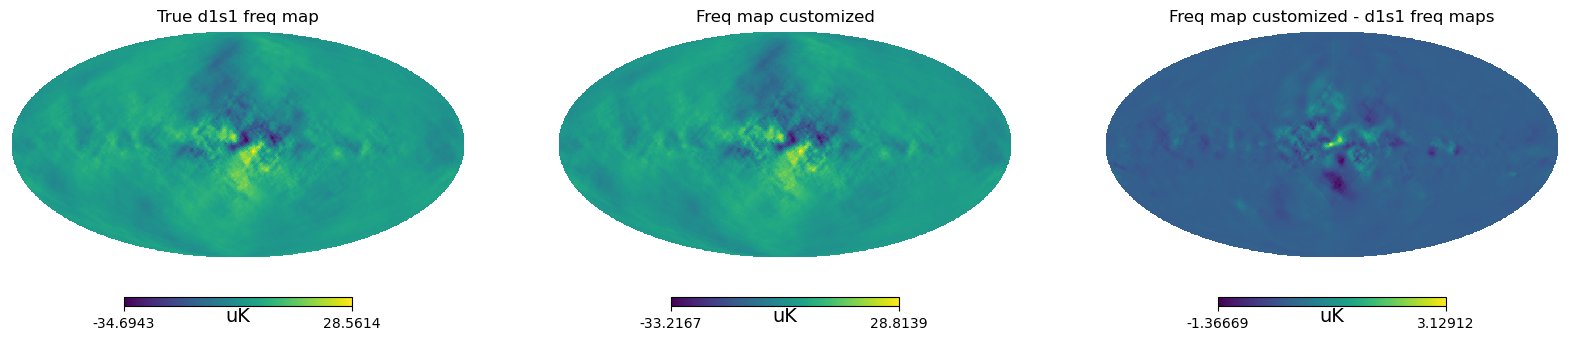

In [7]:
freq_maps_d1s1 = get_observation(instrument, models_unified, noise=False, nside=nside_map)[:, 1:, :]
freq_map_plot_idx = 0
stok_idx = 1

fig, ax = plt.subplots(1, 3, figsize=[20., 10.])
plt.axes(ax[0])
hp.mollview(freq_maps_d1s1[freq_map_plot_idx, stok_idx, :], hold=True, title='True d1s1 freq map', unit='uK')
plt.axes(ax[1])
hp.mollview(freq_maps_fgs_denoised[freq_map_plot_idx, stok_idx, :], hold=True, title='Freq map customized', unit='uK')
plt.axes(ax[2])
hp.mollview(freq_maps_fgs_denoised[freq_map_plot_idx, stok_idx, :]-freq_maps_d1s1[freq_map_plot_idx, stok_idx, :], hold=True, title='Freq map customized - d1s1 freq maps', unit='uK')
plt.show()

### Plot new spectral parameters


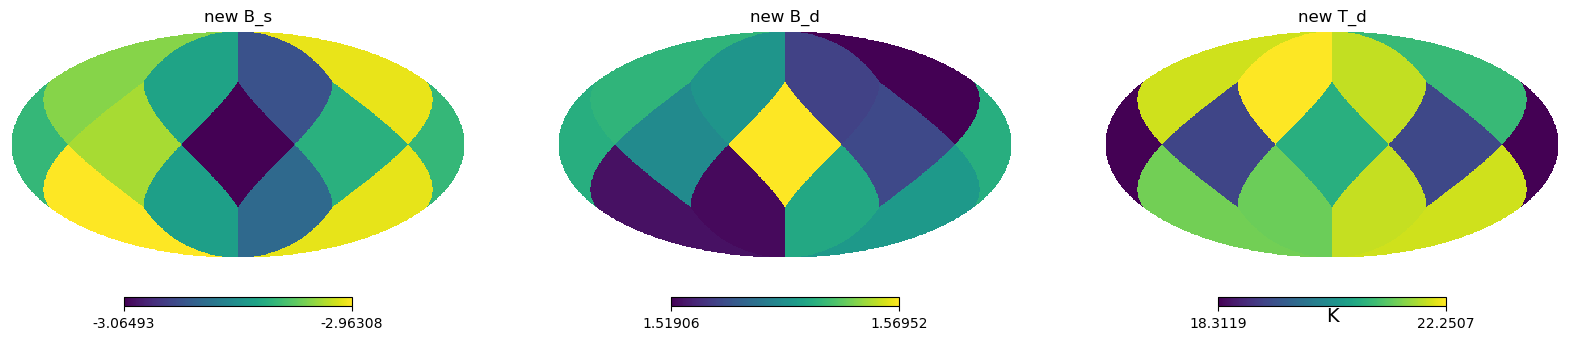

In [8]:
fig, ax = plt.subplots(1, 3, figsize=[20., 10.])
plt.axes(ax[0])
hp.mollview(my_sky_spectral_params[0], hold=True, title='new B_s', unit='')
plt.axes(ax[1])
hp.mollview(my_sky_spectral_params[1], hold=True, title='new B_d', unit='')
plt.axes(ax[2])
hp.mollview(my_sky_spectral_params[2], hold=True, title='new T_d', unit='K')
plt.show()

### Checking the scaling laws of the customized models

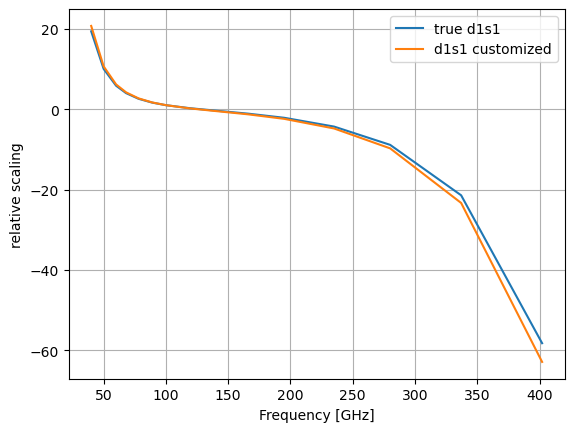

In [9]:
pix_idx = 1000
ref_map_idx = 6

plt.plot(instrument.frequency, freq_maps_d1s1[:, stok_idx, pix_idx]/freq_maps_d1s1[ref_map_idx, stok_idx, pix_idx], label='true d1s1')
plt.plot(instrument.frequency, freq_maps_fgs_denoised[:, stok_idx, pix_idx]/freq_maps_fgs_denoised[ref_map_idx, stok_idx, pix_idx], label='d1s1 customized')
plt.ylabel('relative scaling')
plt.xlabel('Frequency [GHz]')
plt.legend()
plt.grid()

TODO: understand why the scaling is slightly different at high frequency?! It should be exactly the same model still parametric with same scaling laws! Maybe small isssue when downgrading the spectral params in the customized model?

### Parametric comp sep

In [10]:
stokes_lab = ['Q', 'U']
components = [CMB(), Dust(nu0=100.), Synchrotron(nu0=100.)]
comp_lab = ['res', 'dust', 'sync']

In [11]:
result = basic_comp_sep(components, instrument, freq_maps_fgs_denoised, nside=1)   # freq_maps

(array([ 1.54, 20.  , -3.  ]),)
(array([ 1.54, 20.  , -3.  ]),)
(array([ 1.54, 20.  , -3.  ]),)
(array([ 1.54, 20.  , -3.  ]),)
(array([ 1.54, 20.  , -3.  ]),)
(array([ 1.54, 20.  , -3.  ]),)
(array([ 1.54, 20.  , -3.  ]),)
(array([ 1.54, 20.  , -3.  ]),)
(array([ 1.54, 20.  , -3.  ]),)
(array([ 1.54, 20.  , -3.  ]),)
(array([ 1.54, 20.  , -3.  ]),)
(array([ 1.54, 20.  , -3.  ]),)


In [12]:
# explore the results
result.x

array([[ 1.54529378,  1.55207323,  1.51905846,  1.52896115,  1.56952564,
         1.54319852,  1.5507431 ,  1.53010622,  1.52041921,  1.52127479,
         1.54621607,  1.5494606 ],
       [22.25061484, 21.96936309, 20.96631985, 21.8816396 , 20.80250425,
        19.1404272 , 18.31186294, 19.16195243, 21.36548525, 21.41581162,
        21.9686819 , 21.90842361],
       [-3.00588988, -2.98159659, -2.96650103, -3.03939012, -3.06493357,
        -2.97651626, -2.99714198, -3.0002815 , -3.00738853, -2.96308567,
        -2.96702427, -3.03024   ]])

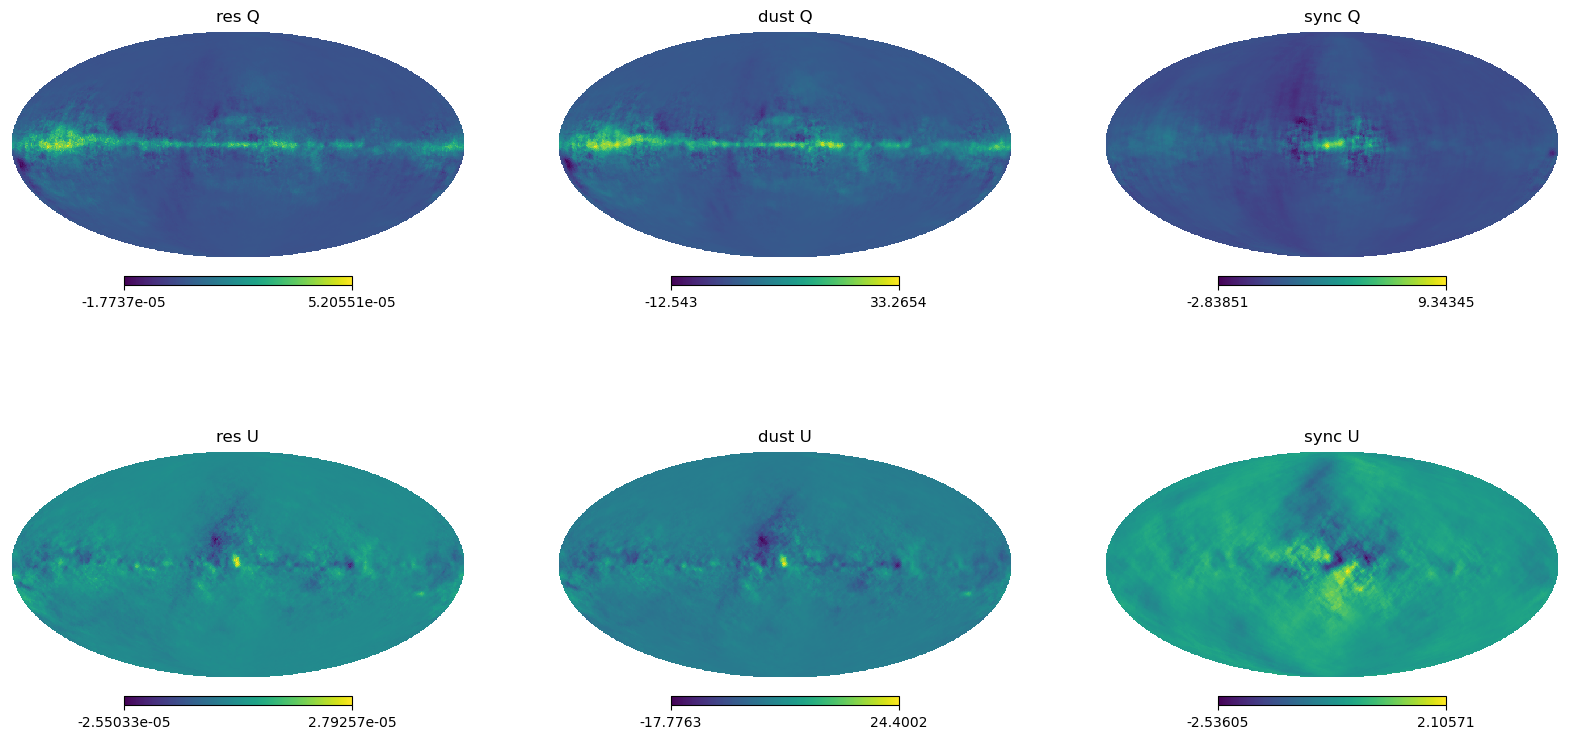

In [13]:
fig, ax = plt.subplots(2, 3, figsize=[20., 10.])
for i in range(np.shape(result.s)[0]):
    for j in range(np.shape(result.s)[1]):
        lab = comp_lab[i] + ' ' + stokes_lab[j]
        plt.axes(ax[j][i])
        hp.mollview(result.s[i, j], hold=True, title=lab)
plt.show()